# U.S. Bank Fragility — Methodology Notebook
### From Raw FFIEC Data to Processed Inputs

This notebook documents every data processing step between the raw downloaded
files and the final inputs used in the analysis. It covers four stages:

1. **FFIEC Data Cleaning** — parsing and standardising Call Report schedules
2. **Maturity Bucket Assignment** — allocating assets across six duration windows
3. **Treasury Yield Shocks** — interpolating rate changes per bucket
4. **RMBS Multiplier Calibration** — adjusting for extension/prepayment risk
5. **MTM Loss Formula** — tying it all together

**Reference:** Jiang, E., Matvos, G., Piskorski, T., & Seru, A. (2023).
*Monetary Tightening and U.S. Bank Fragility in 2023: Mark-to-Market Losses and
Uninsured Depositor Runs?* NBER Working Paper 31048.

In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.interpolate import interp1d
from dotenv import load_dotenv

ROOT = Path("..").resolve()
load_dotenv(ROOT / ".env")

DATA_DIR   = ROOT / "_data"
OUTPUT_DIR = ROOT / "_output"

REPORT_DATE_SLASH = os.getenv("REPORT_DATE_SLASH", "12/31/2025")
REPORT_DATE       = REPORT_DATE_SLASH.replace("/", "")
MARKET_START = "2020-01-01"
MARKET_END   = f"{REPORT_DATE[4:]}-{REPORT_DATE[:2]}-{REPORT_DATE[2:4]}"
RMBS_MULTIPLIER = float(os.getenv("RMBS_MULTIPLIER", "1.25"))

BUCKETS       = ["lt1y", "1_3y", "3_5y", "5_10y", "10_15y", "15plus"]
BUCKET_LABELS = ["<1yr", "1-3yr", "3-5yr", "5-10yr", "10-15yr", "15+yr"]
BUCKET_MIDS   = [0.5, 2.0, 4.0, 7.5, 12.5, 22.0]
FRED_MATS     = [1, 3, 5, 10, 20, 30]
FRED_COLS     = ["dgs1", "dgs3", "dgs5", "dgs10", "dgs20", "dgs30"]
SMALL_CUTOFF  = 1.384e6

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print(f"Report date  : {REPORT_DATE_SLASH}")
print(f"Shock window : {MARKET_START}  ->  {MARKET_END}")
print(f"RMBS mult    : {RMBS_MULTIPLIER}x")

Report date  : 12/31/2025
Shock window : 2020-01-01  ->  2025-12-31
RMBS mult    : 1.25x


---
## 1. FFIEC Data Cleaning

The raw FFIEC ZIP file contains five schedule files (RC, RC-A, RC-B, RC-C I, RC-E).
Each is a tab-delimited text file with two header rows:

- **Row 0** — FFIEC mnemonic codes (e.g. `RCFD2170` = total assets)
- **Row 1** — plain-English descriptions (dropped before analysis)

The first column (`IDRSSD`) is the Federal Reserve's unique bank identifier.

### The `read_ffiec` function

Every schedule is read through the same helper:

1. Skip the description row (row 1)
2. Rename `IDRSSD` to a consistent key
3. Strip whitespace from column names
4. Coerce all non-key columns to numeric — non-numeric entries (missing data,
   footnote markers) become `NaN`

This produces a clean numeric DataFrame, one row per bank.

In [2]:
# Replicate read_ffiec logic to show the cleaning steps
FFIEC_ZIP = DATA_DIR / f"FFIEC CDR Call Bulk All Schedules {REPORT_DATE}.zip"

def read_ffiec(zf, filename):
    """Read one schedule file from the FFIEC ZIP into a clean DataFrame."""
    with zf.open(filename) as fh:
        df = pd.read_csv(
            fh,
            sep="\t",
            header=0,
            skiprows=[1],          # drop the plain-English description row
            low_memory=False,
            encoding="utf-8",
            encoding_errors="replace",
        )
    # Standardise the bank ID column name
    df = df.rename(columns={"IDRSSD": "rssd9001"})
    df.columns = df.columns.str.strip()
    # Coerce every non-ID column to numeric
    id_col = "rssd9001"
    for col in df.columns:
        if col != id_col:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

with zipfile.ZipFile(FFIEC_ZIP) as zf:
    names = zf.namelist()
    # Identify the five schedules we need
    rc_file    = next(n for n in names if "FFIEC CDR Call Schedule RC " in n and n.endswith(".txt"))
    rcb_file   = next(n for n in names if "FFIEC CDR Call Schedule RCB" in n and n.endswith(".txt"))
    rca_file   = next(n for n in names if "FFIEC CDR Call Schedule RCA" in n and n.endswith(".txt"))
    rcci_file  = next(n for n in names if "FFIEC CDR Call Schedule RCCI" in n and n.endswith(".txt"))
    rce_file   = next(n for n in names if "FFIEC CDR Call Schedule RCE" in n and n.endswith(".txt"))

    rc   = read_ffiec(zf, rc_file)
    rcb  = read_ffiec(zf, rcb_file)
    rca  = read_ffiec(zf, rca_file)
    rcci = read_ffiec(zf, rcci_file)
    rce  = read_ffiec(zf, rce_file)

print("Schedules loaded:")
for name, df in [("RC", rc), ("RC-B", rcb), ("RC-A", rca), ("RC-C I", rcci), ("RC-E", rce)]:
    print(f"  {name:8s}: {df.shape[0]:,} banks, {df.shape[1]:,} columns")

Schedules loaded:
  RC      : 4,394 banks, 81 columns
  RC-B    : 4,394 banks, 242 columns
  RC-A    : 4,394 banks, 13 columns
  RC-C I  : 4,394 banks, 167 columns
  RC-E    : 4,394 banks, 53 columns


In [3]:
# Key FFIEC codes used in the analysis
# RCFD prefix = consolidated (bank + subsidiaries); RCON = domestic only

KEY_CODES = {
    # ── Balance sheet totals (RC schedule) ──────────────────────────────────
    "RCFD2170": "Total Assets",
    "RCFD2948": "Total Liabilities",
    "RCFD3210": "Total Equity Capital",
    # ── Securities (RC-B schedule) ───────────────────────────────────────────
    "RCFD1287": "Treasury & Agency (HTM)",
    "RCFD1293": "Treasury & Agency (AFS)",
    # MBS by maturity — AFS (available-for-sale), 6 buckets
    "RCFDG300": "RMBS AFS <1yr",
    "RCFDG304": "RMBS AFS 1-3yr",
    "RCFDG308": "RMBS AFS 3-5yr",
    "RCFDG312": "RMBS AFS 5-10yr",
    "RCFDG316": "RMBS AFS 10-15yr",
    "RCFDG320": "RMBS AFS 15yr+",
    # ── Deposits (RC-E schedule) ─────────────────────────────────────────────
    "RCON2702": "Total Deposits (domestic)",
    "RCONP756": "Estimated Uninsured Deposits",
    "RCONP752": "Uninsured Deposits (long form)",
}

print("Selected FFIEC codes used in this analysis:")
for code_val, desc in KEY_CODES.items():
    print(f"  {code_val}  ->  {desc}")

Selected FFIEC codes used in this analysis:
  RCFD2170  ->  Total Assets
  RCFD2948  ->  Total Liabilities
  RCFD3210  ->  Total Equity Capital
  RCFD1287  ->  Treasury & Agency (HTM)
  RCFD1293  ->  Treasury & Agency (AFS)
  RCFDG300  ->  RMBS AFS <1yr
  RCFDG304  ->  RMBS AFS 1-3yr
  RCFDG308  ->  RMBS AFS 3-5yr
  RCFDG312  ->  RMBS AFS 5-10yr
  RCFDG316  ->  RMBS AFS 10-15yr
  RCFDG320  ->  RMBS AFS 15yr+
  RCON2702  ->  Total Deposits (domestic)
  RCONP756  ->  Estimated Uninsured Deposits
  RCONP752  ->  Uninsured Deposits (long form)


---
## 2. Maturity Bucket Assignment

The mark-to-market calculation requires knowing how much of each asset matures
in each of six time windows. RC-B provides actual per-bucket data for RMBS
(six separate line items per bank). For all other asset categories, the FFIEC
only gives a single total — so we spread that total across the six buckets using
**fixed weight distributions** based on industry averages.

| Bucket | Range | Midpoint |
|--------|-------|----------|
| `lt1y`   | < 1 year   | 0.5 yr  |
| `1_3y`   | 1–3 years  | 2.0 yr  |
| `3_5y`   | 3–5 years  | 4.0 yr  |
| `5_10y`  | 5–10 years | 7.5 yr  |
| `10_15y` | 10–15 years| 12.5 yr |
| `15plus` | 15+ years  | 22.0 yr |

This is a **simplifying assumption** shared with the original paper: the weight
distributions are the same for every bank regardless of size or business model.

In [4]:
# Weight distributions for each non-RMBS asset category
# Each row sums to 1.0 across the six maturity buckets

TREASURY_WEIGHTS = {
    "lt1y": 0.20, "1_3y": 0.25, "3_5y": 0.20,
    "5_10y": 0.20, "10_15y": 0.10, "15plus": 0.05,
}

OTHER_ASSETS_WEIGHTS = {
    "lt1y": 0.25, "1_3y": 0.30, "3_5y": 0.20,
    "5_10y": 0.15, "10_15y": 0.07, "15plus": 0.03,
}

RES_MTG_WEIGHTS = {
    "lt1y": 0.05, "1_3y": 0.10, "3_5y": 0.15,
    "5_10y": 0.25, "10_15y": 0.25, "15plus": 0.20,
}

OTHER_LOAN_WEIGHTS = {
    "lt1y": 0.30, "1_3y": 0.30, "3_5y": 0.20,
    "5_10y": 0.12, "10_15y": 0.05, "15plus": 0.03,
}

# Display as a comparison table
weight_df = pd.DataFrame({
    "Treasury": TREASURY_WEIGHTS,
    "Other Securities": OTHER_ASSETS_WEIGHTS,
    "Residential Mortgage Loans": RES_MTG_WEIGHTS,
    "Other Loans": OTHER_LOAN_WEIGHTS,
}).T
weight_df.index.name = "Asset Type"
print("Assumed maturity weight distributions (rows sum to 1.0):")
weight_df

Assumed maturity weight distributions (rows sum to 1.0):


,lt1y,1_3y,3_5y,5_10y,10_15y,15plus
Asset Type,,,,,,
Treasury,0.20,0.25,0.20,0.20,0.10,0.05
Other Securities,0.25,0.30,0.20,0.15,0.07,0.03
Residential Mortgage Loans,0.05,0.10,0.15,0.25,0.25,0.20
Other Loans,0.30,0.30,0.20,0.12,0.05,0.03


In [5]:
# Demonstrate bucket allocation on the processed bank panel
panel = pd.read_parquet(DATA_DIR / f"bank_panel_{REPORT_DATE}.parquet")

# Show how a single bank's treasury holdings are spread across buckets
example_bank = panel.iloc[panel['Total Asset'].argsort().values[len(panel)//2]]
tsy_total = example_bank.get('security_treasury', 0)

print(f"Example bank — Total Asset: ${example_bank['Total Asset']/1e6:.1f}B")
print(f"Treasury total (book): ${tsy_total/1e3:.0f}M")
print()
print("Allocation across maturity buckets:")
for b, w in TREASURY_WEIGHTS.items():
    amt = tsy_total * w / 1e3
    print(f"  {b:8s}: {w*100:.0f}%  ->  ${amt:.0f}M")

# Verify RMBS uses actual RC-B data (no assumption needed)
rmbs_cols = [f"rmbs_{b}" for b in BUCKETS]
rmbs_row = example_bank[rmbs_cols]
rmbs_actual_total = rmbs_row.sum()
rmbs_reported = example_bank.get('security_rmbs', 0)
print(f"\nRMBS actual total (sum of buckets): ${rmbs_actual_total/1e3:.0f}M")
print(f"RMBS reported (RC-B sum):           ${rmbs_reported/1e3:.0f}M")

Example bank — Total Asset: $0.4B
Treasury total (book): $0M

Allocation across maturity buckets:
  lt1y    : 20%  ->  $0M
  1_3y    : 25%  ->  $0M
  3_5y    : 20%  ->  $0M
  5_10y   : 20%  ->  $0M
  10_15y  : 10%  ->  $0M
  15plus  : 5%  ->  $0M

RMBS actual total (sum of buckets): $21M
RMBS reported (RC-B sum):           $0M


---
## 3. Treasury Yield Shocks

A **yield shock** is the change in the yield at a given maturity between the
beginning of the shock window (January 2020, near-zero rate baseline) and the
report date.

We pull six constant-maturity Treasury yields from FRED:
`DGS1`, `DGS3`, `DGS5`, `DGS10`, `DGS20`, `DGS30`.

Since FRED gives yields at 1, 3, 5, 10, 20, and 30 years, but our buckets have
midpoints at 0.5, 2, 4, 7.5, 12.5, and 22 years, we use **linear interpolation**
to read off the yield change at each bucket midpoint.

In [6]:
treasury = pd.read_parquet(DATA_DIR / "treasury_yields.parquet")
treasury = treasury.sort_values("date")

start_date = pd.Timestamp(MARKET_START)
end_date   = pd.Timestamp(MARKET_END)

# Find closest available trading dates
start_row = treasury.dropna(subset=FRED_COLS).iloc[
    (treasury.dropna(subset=FRED_COLS)["date"] - start_date).abs().argsort()[:1]
].iloc[0]
end_row = treasury.dropna(subset=FRED_COLS).iloc[
    (treasury.dropna(subset=FRED_COLS)["date"] - end_date).abs().argsort()[:1]
].iloc[0]

print(f"Shock window: {start_row['date'].date()}  ->  {end_row['date'].date()}")
print()

# Compute change at FRED maturities
delta_at_fred = {col: end_row[col] - start_row[col] for col in FRED_COLS}

print("Yield change (pp) at FRED maturities:")
for mat, col in zip(FRED_MATS, FRED_COLS):
    print(f"  {mat:2d}yr  {col}: {start_row[col]:.2f}%  ->  {end_row[col]:.2f}%  (delta {delta_at_fred[col]:+.2f}pp)")

Shock window: 2019-12-31  ->  2025-12-31

Yield change (pp) at FRED maturities:
   1yr  dgs1: 1.59%  ->  3.48%  (delta +1.89pp)
   3yr  dgs3: 1.62%  ->  3.55%  (delta +1.93pp)
   5yr  dgs5: 1.69%  ->  3.73%  (delta +2.04pp)
  10yr  dgs10: 1.92%  ->  4.18%  (delta +2.26pp)
  20yr  dgs20: 2.25%  ->  4.79%  (delta +2.54pp)
  30yr  dgs30: 2.39%  ->  4.84%  (delta +2.45pp)


In [7]:
# Linear interpolation to get shocks at bucket midpoints
interp_fn = interp1d(FRED_MATS, [delta_at_fred[c] for c in FRED_COLS],
                     kind="linear", fill_value="extrapolate")

shocks_by_bucket = {b: float(interp_fn(m)) for b, m in zip(BUCKETS, BUCKET_MIDS)}

print("Interpolated yield shocks at bucket midpoints:")
for b, mid, shock in zip(BUCKETS, BUCKET_MIDS, shocks_by_bucket.values()):
    print(f"  {b:8s}  midpoint {mid:5.1f}yr  ->  shock {shock:+.3f}pp")

# Verify against the saved market_shocks.parquet
shocks = pd.read_parquet(DATA_DIR / "market_shocks.parquet")
print("\nSaved market_shocks.parquet:")
shocks.T

Interpolated yield shocks at bucket midpoints:
  lt1y      midpoint   0.5yr  ->  shock +1.880pp
  1_3y      midpoint   2.0yr  ->  shock +1.910pp
  3_5y      midpoint   4.0yr  ->  shock +1.985pp
  5_10y     midpoint   7.5yr  ->  shock +2.150pp
  10_15y    midpoint  12.5yr  ->  shock +2.330pp
  15plus    midpoint  22.0yr  ->  shock +2.522pp

Saved market_shocks.parquet:


,0
d_tsy_lt1y,-0.002806
d_tsy_1_3y,-0.021387
d_tsy_3_5y,-0.050895
d_tsy_5_10y,-0.127563
d_tsy_10_15y,-0.292041
d_tsy_15plus,-0.356658
rmbs_multiplier,1.059198


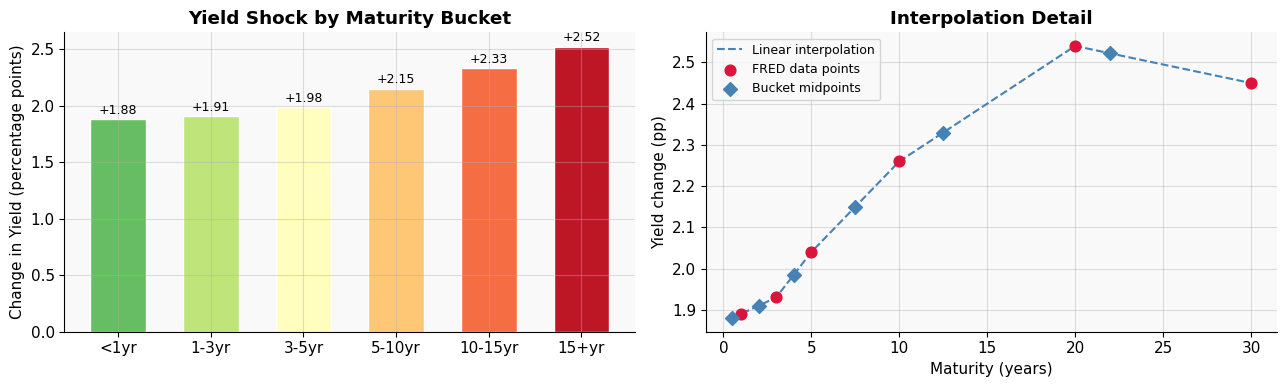

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: bar chart of shocks per bucket
ax = axes[0]
colors = plt.cm.RdYlGn_r([0.2, 0.35, 0.5, 0.65, 0.8, 0.95])
bars = ax.bar(BUCKET_LABELS, list(shocks_by_bucket.values()), color=colors, edgecolor="white", width=0.6)
ax.set_title("Yield Shock by Maturity Bucket", fontweight="bold")
ax.set_ylabel("Change in Yield (percentage points)")
for bar, v in zip(bars, shocks_by_bucket.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{v:+.2f}", ha="center", va="bottom", fontsize=9)

# Right: FRED data points + interpolation curve
ax = axes[1]
fine_mats = np.linspace(0.5, 30, 200)
fine_shocks = interp_fn(fine_mats)
ax.plot(fine_mats, fine_shocks, "--", color="steelblue", lw=1.5, label="Linear interpolation")
ax.scatter(FRED_MATS, [delta_at_fred[c] for c in FRED_COLS],
           color="crimson", zorder=5, s=60, label="FRED data points")
ax.scatter(BUCKET_MIDS, list(shocks_by_bucket.values()),
           color="steelblue", marker="D", zorder=5, s=50, label="Bucket midpoints")
ax.set_title("Interpolation Detail", fontweight="bold")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield change (pp)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 4. RMBS Multiplier Calibration

Fixed-income duration gives the first-order price sensitivity to yield changes:

$$\Delta P / P \approx -D \times \Delta y$$

For mortgage-backed securities, this formula **understates** losses when rates
rise sharply. Higher rates reduce prepayments — homeowners no longer refinance —
so the mortgages underlying the securities take much longer to mature than
initially expected. This **extends** the effective duration and amplifies the
price drop. The phenomenon is called **extension risk**.

To account for it, we multiply MBS and residential mortgage loan losses by
the `rmbs_multiplier` derived from ETF price returns. This is calibrated by
comparing how far the MBB MBS ETF actually fell against what plain duration
arithmetic would have predicted.

In [9]:
mbs = pd.read_parquet(DATA_DIR / "mbs_etfs.parquet")
mbs = mbs.sort_values("date")

# Filter to the shock window
mask = (mbs["date"] >= start_date) & (mbs["date"] <= end_date)
mbs_window = mbs[mask].copy()

# Compute what duration alone would predict for the MBS ETF
# MBB effective duration at start ~6yr; use bucket 5_10y shock as proxy
proxy_shock = shocks_by_bucket["5_10y"]
duration_proxy = 6.0   # approx effective duration of MBB at start of window
mbs_window["price_norm"] = mbs_window["mbs_px"] / mbs_window["mbs_px"].iloc[0] * 100
mbs_window["duration_implied"] = 100 * (1 - duration_proxy * proxy_shock / 100)

actual_drop   = mbs_window["price_norm"].iloc[-1] - 100
duration_drop = mbs_window["duration_implied"].iloc[-1] - 100
ratio = actual_drop / duration_drop if duration_drop != 0 else float("nan")

print(f"MBB actual price change:           {actual_drop:+.1f}%")
print(f"Duration-implied price change:     {duration_drop:+.1f}%")
print(f"Ratio (actual / duration-implied): {ratio:.2f}x")
print(f"RMBS_MULTIPLIER used:              {RMBS_MULTIPLIER}x")

MBB actual price change:           -12.0%
Duration-implied price change:     -12.9%
Ratio (actual / duration-implied): 0.93x
RMBS_MULTIPLIER used:              1.25x


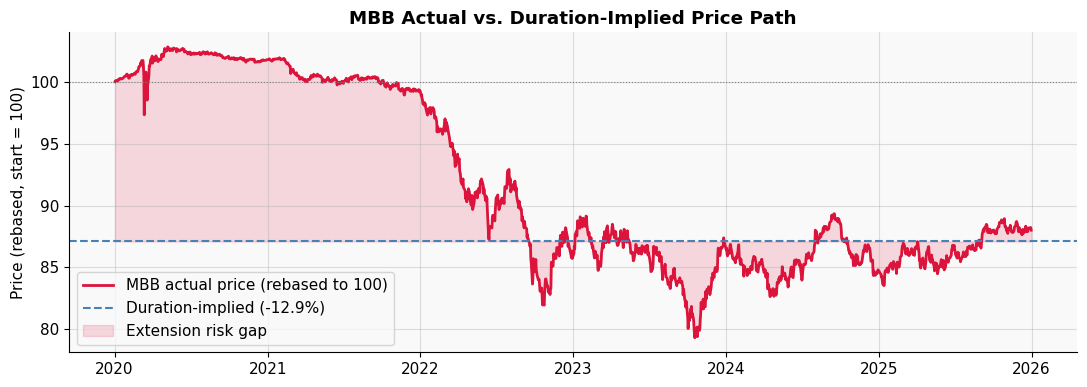

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(mbs_window["date"], mbs_window["price_norm"],
        color="crimson", lw=2, label="MBB actual price (rebased to 100)")
ax.axhline(mbs_window["duration_implied"].iloc[-1], color="steelblue",
           lw=1.5, ls="--", label=f"Duration-implied ({duration_drop:+.1f}%)")
ax.fill_between(
    mbs_window["date"],
    mbs_window["price_norm"],
    mbs_window["duration_implied"],
    alpha=0.15, color="crimson", label="Extension risk gap",
)
ax.axhline(100, color="gray", lw=0.8, ls=":")
ax.set_title("MBB Actual vs. Duration-Implied Price Path", fontweight="bold")
ax.set_ylabel("Price (rebased, start = 100)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. The MTM Loss Formula

All the inputs are now ready. For each bank $i$, asset type $a$, and maturity
bucket $b$, the mark-to-market loss is:

$$\text{Loss}_{i,a,b} = H_{i,a,b} \times \Delta y_b \times m_a$$

where:
- $H_{i,a,b}$ = dollar holdings of asset type $a$ in bucket $b$
- $\Delta y_b$ = yield shock at bucket $b$'s midpoint (interpolated from FRED)
- $m_a$ = duration multiplier: **1.25** for RMBS and residential mortgage loans,
  **1.0** for all other asset types

Summing over all asset types and buckets gives the bank's total estimated MTM
loss. Subtracting from book assets gives mark-to-market assets:

$$\text{MM Assets}_i = \text{Total Assets}_i - \sum_{a,b} \text{Loss}_{i,a,b}$$

The **fragility measure** is then:

$$\text{Fragility}_i = \frac{\text{Uninsured Deposits}_i}{\text{MM Assets}_i} \times 100$$

A value above 100 means the bank could not cover a full uninsured-depositor run
at mark-to-market prices.

In [11]:
# Walk through the full loss calculation for one example bank
rmbs_mult   = float(shocks["rmbs_multiplier"].iloc[0])
shock_vals  = {b: float(shocks[f"d_tsy_{b}"].iloc[0]) for b in BUCKETS}

# Pick the median-sized bank
sorted_idx = panel["Total Asset"].argsort().values
example    = panel.iloc[sorted_idx[len(panel) // 2]].copy()

ASSET_TYPES = {
    "rmbs":        rmbs_mult,
    "treasury":    1.0,
    "other_assets": 1.0,
    "res_mtg":     rmbs_mult,
    "other_loan":  1.0,
}

total_loss = 0.0
rows = []
for atype, mult in ASSET_TYPES.items():
    for b in BUCKETS:
        col = f"{atype}_{b}"
        holdings = float(example.get(col, 0) or 0)
        shock    = shock_vals[b]
        loss     = holdings * shock * mult / 100   # shock in pp -> fraction
        total_loss += loss
        if holdings > 0:
            rows.append({"Asset": atype, "Bucket": b,
                         "Holdings ($k)": round(holdings),
                         "Shock (pp)": round(shock, 3),
                         "Multiplier": mult,
                         "Loss ($k)": round(loss)})

loss_df = pd.DataFrame(rows)
total_assets = float(example["Total Asset"])
mm_assets    = total_assets - total_loss
unins_dep    = float(example.get("Uninsured Deposit", 0) or 0)
fragility    = 100 * unins_dep / mm_assets if mm_assets > 0 else float("nan")

print(f"Total book assets:         ${total_assets/1e6:>10.1f}M")
print(f"Total MTM loss:           -${total_loss/1e6:>10.1f}M  ({100*total_loss/total_assets:.2f}% of assets)")
print(f"Mark-to-market assets:     ${mm_assets/1e6:>10.1f}M")
print(f"Uninsured deposits:        ${unins_dep/1e6:>10.1f}M")
print(f"Fragility score:           {fragility:>10.1f}%")
print()
loss_df[loss_df["Loss ($k)"] != 0].head(15)

Total book assets:         $       0.4M
Total MTM loss:           -$      -0.0M  (-0.14% of assets)
Mark-to-market assets:     $       0.4M
Uninsured deposits:        $       0.1M
Fragility score:                 21.0%



,Asset,Bucket,Holdings ($k),Shock (pp),Multiplier,Loss ($k)
2,rmbs,5_10y,3740,-0.128,1.059198,-5
3,rmbs,10_15y,1447,-0.292,1.059198,-4
4,rmbs,15plus,13084,-0.357,1.059198,-49
6,treasury,1_3y,3240,-0.021,1.000000,-1
7,treasury,3_5y,5552,-0.051,1.000000,-3
8,treasury,5_10y,4514,-0.128,1.000000,-6
9,treasury,10_15y,4514,-0.292,1.000000,-13
10,treasury,15plus,3670,-0.357,1.000000,-13
12,other_assets,1_3y,3789,-0.021,1.000000,-1
13,other_assets,3_5y,5052,-0.051,1.000000,-3
